# Table of contents

## 1. Define the Problem & Goals

This is a transnational dataset that contains all transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based, registered non-store online retail company. The company mainly sells unique all-occasion gifts. Many of the company's customers are wholesalers.

Link to the dataset - [here](https://www.kaggle.com/datasets/carrie1/ecommerce-data).

The primary objective of this project is to develop a user segmentation framework based on the provided dataset, with the aim of **delivering customized offers**. The secondary objective is to conduct an analysis and segmentation for **target campaigns**. The available data includes information such as the types of goods purchased by customers, their geographical locations, and the quantity of goods sold for each type. This data enables detailed customer data segmentation, which is essential for effective marketing strategies.

According to the available data, the upcoming analytical assessment will be <span style="color:red">limited</span> by the following factors:
- Data covers only one year (2010–2011).
- Focus is on UK-based transactions, may not represent global trends.
- Lacks detailed demographic/psychographic information, so segmentation will rely on transaction patterns.

---
**User segmentation** - is the process of separating users into distinct groups, or segments, based on shared characteristics. A company might segment users based on language preferences, product version, geographical region, or user persona.

**The most common types of user segments:**
- **Demographic:** Information about the individual user, such as their age, location, language preferences, title, or role.
- **Firmographic:** Information about the user’s organization, like industry, revenue, employee count, or business model.
- **Technographic:** Information on the other technologies the user’s organization uses, including CRM provider, marketing automation tools, back office systems, or databases.
- **Customer data:** Information stored in a CRM about the customer’s relationship with the company, such as plan type, customer journey stage, annual revenue, account owner, or renewal date.
- **Behavioral:** Information about how the individual user has interacted with the product, including number of logins, pages viewed, features clicked, support tickets created, and time on site.
- **Psychographic:** Information on a user’s likes and dislikes, including product sentiment. This data can be captured with measures like Customer Satisfaction (CSAT) or Net Promoter Score (NPS).

---
The main objective of customer segmentation for the target e-commerce company is to develop unique sales and communication strategies for each segment based on data analysis and customer behavior. Completing the customer segmentation strategy will allow the company to reach its full potential, strengthen consumer loyalty, and optimize the marketing budget. Therefore, the objective of this analysis is to understand the company's heterogeneous customer base. Without segmentation, marketing campaigns are less effective, leading to wasted budget and reduced customer engagement. Thus, the main goals and business results are formulated as follows:
1) Delivering personalized offers - higher conversion rate;
2) Targeted campaigns - reduced customer churn and increased retention.

According to the dataset, **the primary objective** is to **create meaningful customer segments using transaction data**. The secondary goals are to answer the following questions:
- What are the main groups of customers buying from the company?
- Who are the most frequent buyers?
- Who are the highest-spending customers?
- Who are the lower-spending customers?
- Which customers bring in the most profit?

The following deliverables are anticipated:
- Implement a segmentation framework using clustering methods.
- Profiles of customer segments are presented in summary tables and visualizations.
- The final business recommendations are based on the results obtained.


## 2. Data Collection & Cleaning

Begin the data understanding process by loading the customer dataset, examining the variables, and identifying any missing values.

### 2.1. Load necessary libraries

In [49]:
import matplotlib.pyplot as plt # Data visualization
import matplotlib.patheffects as pe
import numpy as np # linear algebra
import pandas as pd # Data processing

import missingno as msno # Analyze data for missing values

### 2.2. Loading the dataset

In [50]:
df = pd.read_csv('D:/Google Drive/Work/Data Analytics and Data Science/Roadpam/project_1-customer-segmentation/data/raw/e-commerce-data-raw.csv', encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [51]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


Upon loading the dataset, it was ascertained that it determined ***541909*** records (rows) and ***8*** attributes (columns). The columns of the dataset can be described in the following way: 
- 4 columns are a numeric type of data;
- 2 text type (In case of making a dashboard report, it is possible to change the *Country* column to a geographical data type);
- 1 date/time column - *InvoiceDate* which should be transformed into two separate columns *InvoiceDate* and *InvoiceTime*.

The brief
|№  |Column name|Column description|Data type|Parameters|
|---|---|---|---|---|
|1  |**InvoiceNo**|A unique identifier assigned to each transaction|object| |
|2  |**StockCode**|An internationally standardized system of names and numbers to classify traded products|object| |
|3  |**Description**|A description of the trade product|object| |
|4  |**Quantity**|The quantity of units of a product in a transaction|int64 | |
|5  |**InvoiceDate**|The date and time of the transaction|object| |
|6  |**UnitPrice**|The unit price of the product is expressed in sterling|float64| |
|7  |**CustomerID**|A unique identifier assigned to each customer|float64| |
|8  |**Country**|The country of the customer|object| |

Before the first step of analysis, 
1. Note to description that CustomerID and Description have a lot of missing values
2. Transform InvoiceDate to date/time and split
3. Change the alias of the column name

### 2.3. Preliminary summary analysis

Before starting the data cleaning procedure it is necessary to survey the summary statistics of the entire dataset. This will provides the initial insights into the data distribution and identifies any inconsistencies that could affect on the analysis.

In [53]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


In [54]:
df['CustomerID'] = df['CustomerID'].astype('object')

In [55]:
df.describe(include = 'object').T

,count,unique,top,freq
InvoiceNo,541909,25900,573585,1114
StockCode,541909,4070,85123A,2313
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369
InvoiceDate,541909,23260,10/31/2011 14:41,1114
CustomerID,406829.0,4372.0,17841.0,7983.0
Country,541909,38,United Kingdom,495478


**Results and conclusions for each column**

The following are the initial results of the analysis, which are also questions that should be answered in future steps.
1. Quantity:
    - The significant difference between the **mean** ($\approx 9.55$) and the **median** ($3.00$). This should be considered to understand and analyze the distribution form;
    - The **min** value ($\text{-80995.0}$) should be considered and surveyed, which suggests an unexpected business event like returns or cancellations;
    - The huge significant deviation **std** ($\approx 218.08$) along with the significant **max** value ($\text{80995.0}$) on the overall data considering the **75%** percentile value could indicate a high level of skewness and possible presence of outliers in the data.

2. UnitPrice:
    - The more than double difference between the **mean** ($4.61$) and and the median (**50%**) ($2.008$). Should be analysed to understand the distribution form, the values suggest a potential for a strong positive skew distribution;
    - The **min** value ($\text{-11062.06}$) should be considered and surveyed, which suggests an unexpected business event like returns or cancellations;
    - The significant difference between **75%** percentile ($4.13$) and **max** value ($\text{38970.0}$), which may indicate that certain luxury items have a significantly higher price, or it may suggest an administrative entry or a substantial outlier.

3. CustomerID:
    - The value of the **count** parameter ($406829.0$) indicates the presence of missing values, which is critical for the current task (customer segmentation). A procedure for cleaning up missing values is required;
    - After converting the *CustomerID* to an *object* data type, we obtained additional information:
        - Total of $4372$ **unique** custemers, which may include both potential individuals[] and businesses;
        - One *CustomerID* ($17841$) appears **freq** ($7983$) times. Should check transaction of this customers, it could be the most "active" customer or a massive outlier compared to the average.

4. InvoiceNo:
    - According to the statistical data, the dataset contains $25900$ unique transactions;
    - The *InvoiceNo* - $573585$ appears **freq** $1114$ times. This could indicate a large wholesale client or a very diverse shopping cart.

5. StockCode:
    - Dataset contains the $4070$ **unique** items;
    - The *Stockcode* $85123A$ appears **unique** $2313$ times, which this stage of the analysis, it can be designated as the best-selling product.

6. Description:
    - The value of the **count** parameter ($540455$) indicates the presence of missing values; 
    - The number of **unique** ($4223$) values ​​differs from the number in the *StockCode* column. This should be looked into further as it may indicate administrative adjustments, damaged items, or "lost" items rather than actual sales. It is also possible that different character cases were used in various item descriptions;
    - The value of the **freq* parameter ($2313$), ​​differs from the value in the *StockCode* column. This could indicate that there are multiple different *StockCodes* with the same *Description*.

7. InvoiceDate:
    - The number of **unique** values ($23260$) is close to the number of unique values ​of InvoiceNo column. This verifies the reliability of the data in relation to this particular aspect;
    - The timestamp ($10/31/2011 14:41$) apperas **freq** $1114$ times. This confirms the assumption that the order was completed by a large wholesale client or through a diverse shopping cart;

8. Country:
    - Country ($United Kingdom$) appears among ($38$) **unique** values **freq** ​(​$495478$) times, which is ($\approx 94\%$) of the total number of transactions. This suggests that the data is primarily focused on the United Kingdom market.

### 2.4. Data cleaning and transformation

First of all, it is necessary to perform dropping `NAN` values and duplicates to exclude inaccurate initial summary statistics.

#### 2.4.1. Detect and drop `NAN` values

First, visualize the number of missing values using the *missingno* library.

<Axes: >

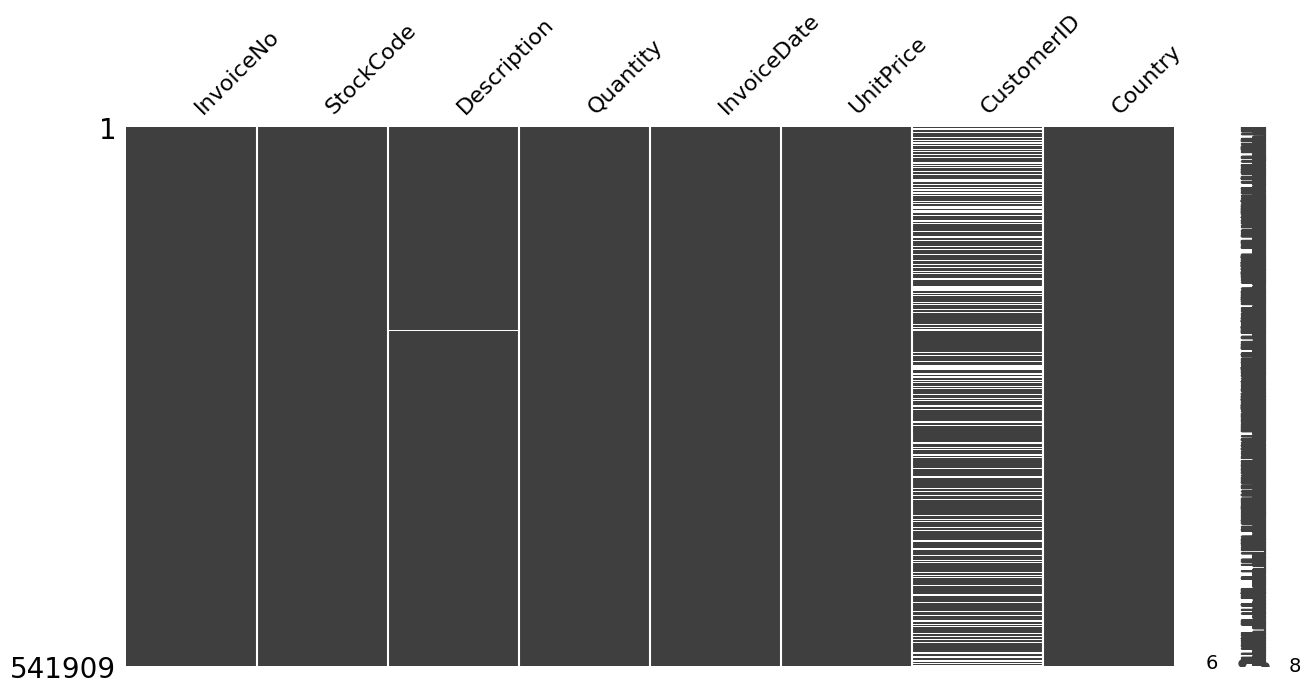

In [56]:
msno.matrix(df, figsize=(15, 7))

Then display the columns containing missing values on the chart, as well as the percentage of the total number of these values.

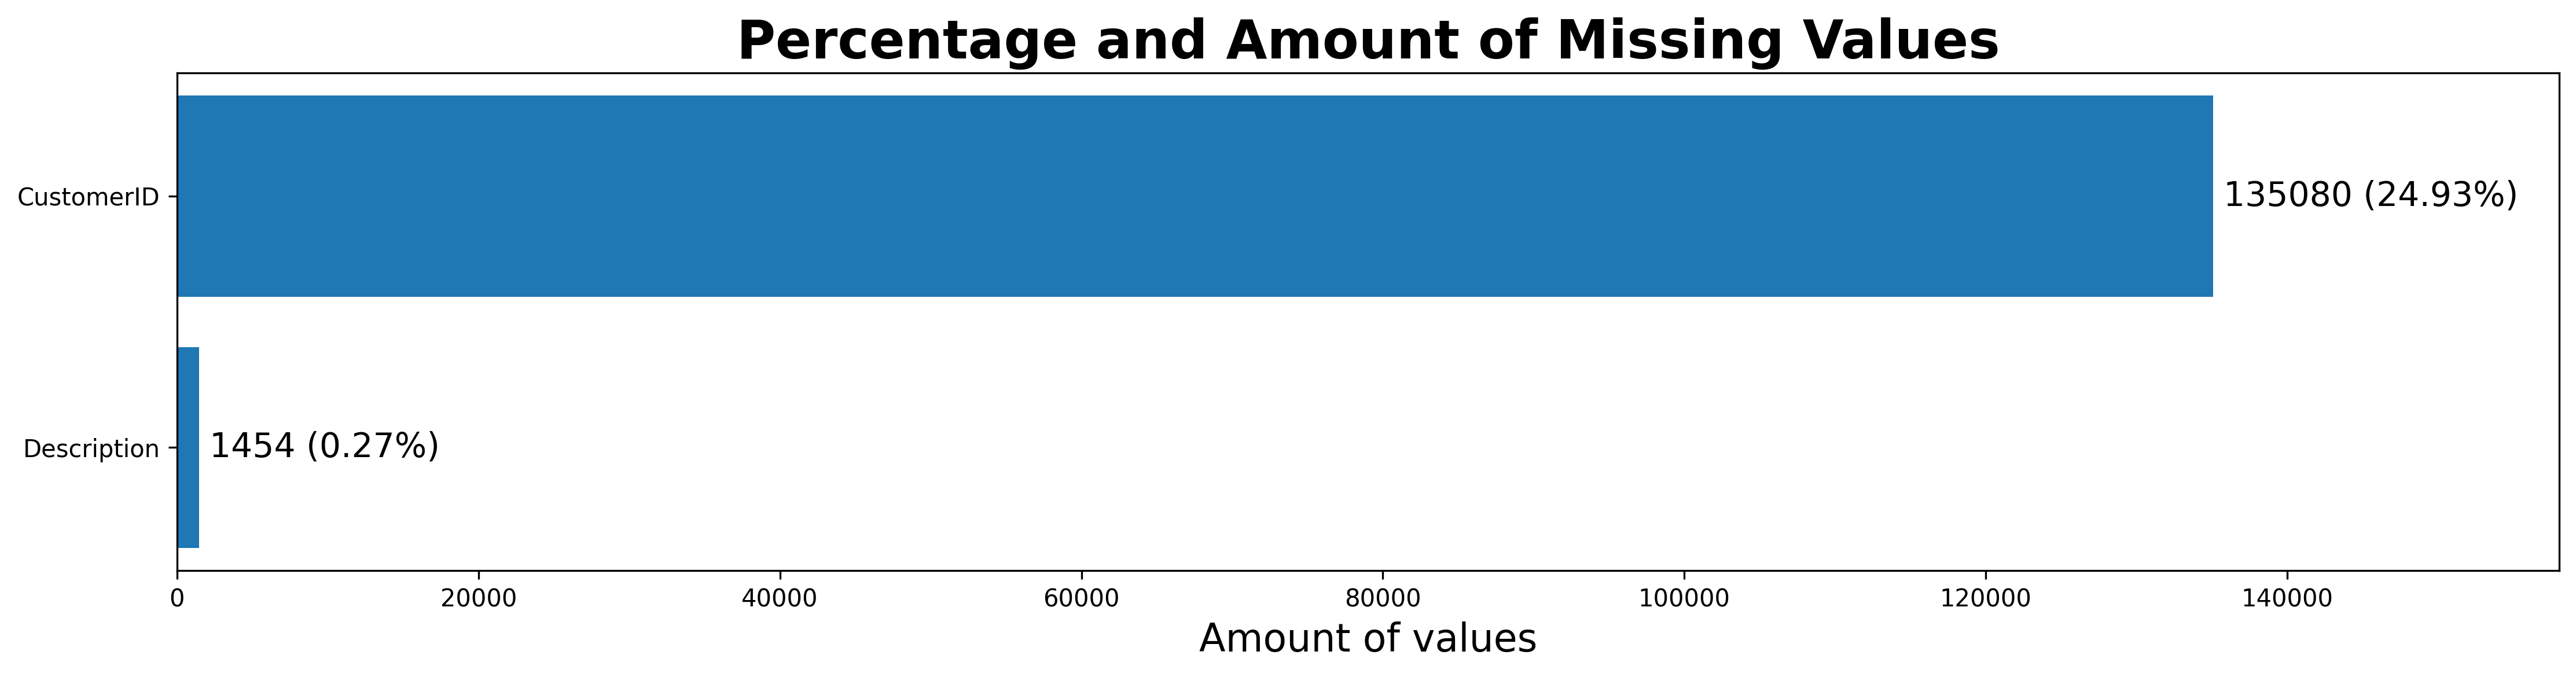

In [57]:
missing_data = df.isnull().sum()
missing_data_percentage = (missing_data[missing_data > 0] / df.shape[0]) * 100

missing_data = missing_data[missing_data > 0]
missing_data.sort_values(ascending = True, inplace = True)

missing_data_percentage.sort_values(ascending = True, inplace = True)

fig, ax = plt.subplots(figsize = (15, 4), dpi = 300)
ax.barh(missing_data.index, missing_data)

for i, (value_1, value_2, name) in enumerate(zip(missing_data, missing_data_percentage, missing_data_percentage.index)):
    ax.text(value_1+700, i, f"{value_1} ({value_2:.2f}%)", va = 'center', ha = 'left', fontsize=14)

ax.set_xlim([0, value_1*1.17])

plt.title("Percentage and Amount of Missing Values", fontweight = 'bold', fontsize = 22)
plt.xlabel('Amount of values', fontsize=16)
plt.tight_layout()

In [58]:
df[df['CustomerID'].isnull() | df['Description'].isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom


In [59]:
df_na_cleaned = df.dropna()
df_na_cleaned.info()
print("\nVerifying the removal of missing values ",df_na_cleaned.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  object 
 7   Country      406829 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 27.9+ MB

Verifying the removal of missing values  0


#### 2.4.2. Remove dublicate:

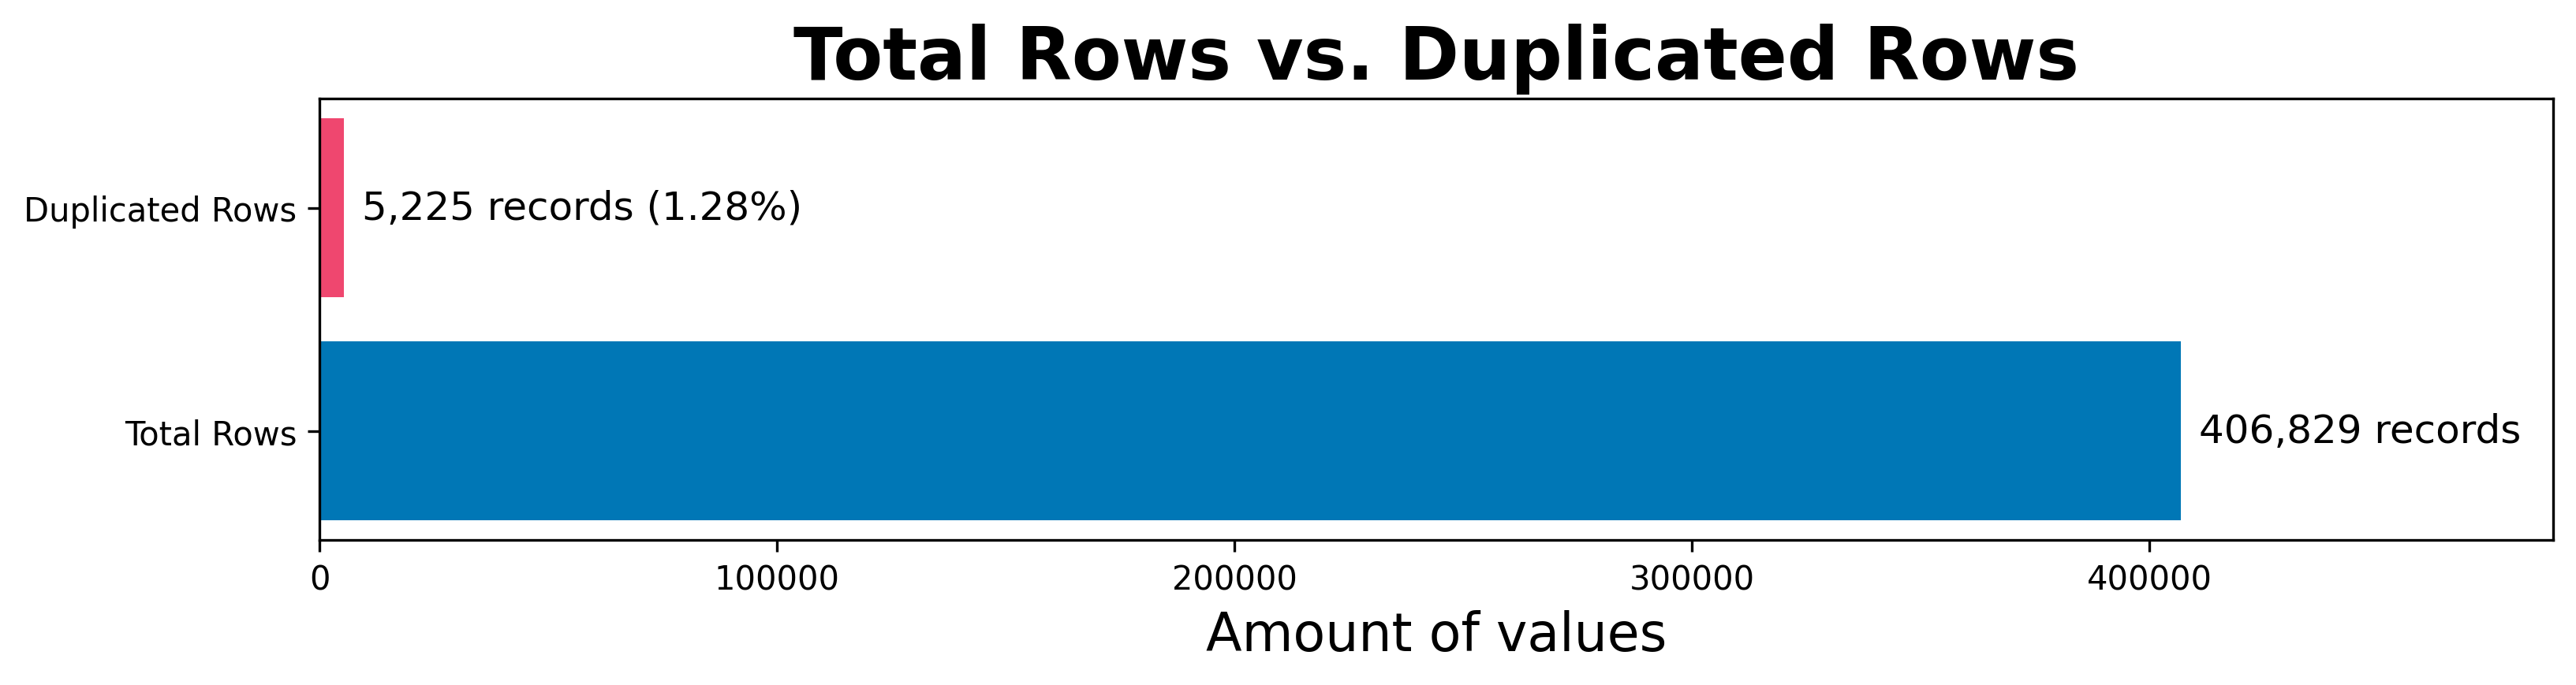

In [60]:
duplicated_data = df_na_cleaned.duplicated().sum()
dublicated_data_percentage = float((duplicated_data / df_na_cleaned.shape[0]) * 100)
total_rows = df_na_cleaned.shape[0]

data_labels = ['Total Rows', 'Duplicated Rows']
data_values = [total_rows, duplicated_data]
colors = ['#0077b6', '#ef476f']
fig, ax = plt.subplots(figsize = (11, 3), dpi = 300)

bars = ax.barh(data_labels, data_values, color = colors)

for i, bar in enumerate(bars):
    value = bar.get_width()
    if i == 0:
        label = f'{value:,} records'
    else:
        label = f'{value:,} records ({dublicated_data_percentage:.2f}%)'
    ax.text(value + 4000, i, label, va = 'center', ha = 'left', fontsize = 12)

ax.set_xlim(0, total_rows * 1.2)
ax.set_title('Total Rows vs. Duplicated Rows', fontweight = 'bold', fontsize = 22)
plt.xlabel('Amount of values', fontsize = 16)
plt.tight_layout()
plt.show()

In [61]:
df_na_dp_cleaned = df_na_cleaned.drop_duplicates()
df_na_dp_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    401604 non-null  object 
 1   StockCode    401604 non-null  object 
 2   Description  401604 non-null  object 
 3   Quantity     401604 non-null  int64  
 4   InvoiceDate  401604 non-null  object 
 5   UnitPrice    401604 non-null  float64
 6   CustomerID   401604 non-null  object 
 7   Country      401604 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 27.6+ MB


#### 2.4.3. Trim white spaces in the column data

In [62]:
def trim_whitespace(dataframe):
    for i in dataframe.columns:
        if dataframe[i].dtype == 'object':
            dataframe[i] = dataframe[i].map(str.strip)
        else:
            pass

In [63]:
df_na_dp_cleaned['InvoiceNo'].str.strip()
df_na_dp_cleaned['StockCode'].str.strip()
df_na_dp_cleaned['Description'].str.strip()
df_na_dp_cleaned['Country'].str.strip()

df_na_dp_cleaned.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


#### 2.4.4. Detecting and removing canceled orders
Check the data for canceled order, to withdraw from dataset

In [64]:
df_canceled = df_na_dp_cleaned[df_na_dp_cleaned['InvoiceNo'].str.contains(r'[C]', regex = True)]
df_canceled.to_csv('D:/Google Drive/Work/Data Analytics and Data Science/Roadpam/project_1-customer-segmentation/data/processed/e-commerce-data-canceled.csv')
df_canceled.info()
df_canceled.head()

<class 'pandas.core.frame.DataFrame'>
Index: 8872 entries, 141 to 541717
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    8872 non-null   object 
 1   StockCode    8872 non-null   object 
 2   Description  8872 non-null   object 
 3   Quantity     8872 non-null   int64  
 4   InvoiceDate  8872 non-null   object 
 5   UnitPrice    8872 non-null   float64
 6   CustomerID   8872 non-null   object 
 7   Country      8872 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 623.8+ KB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom


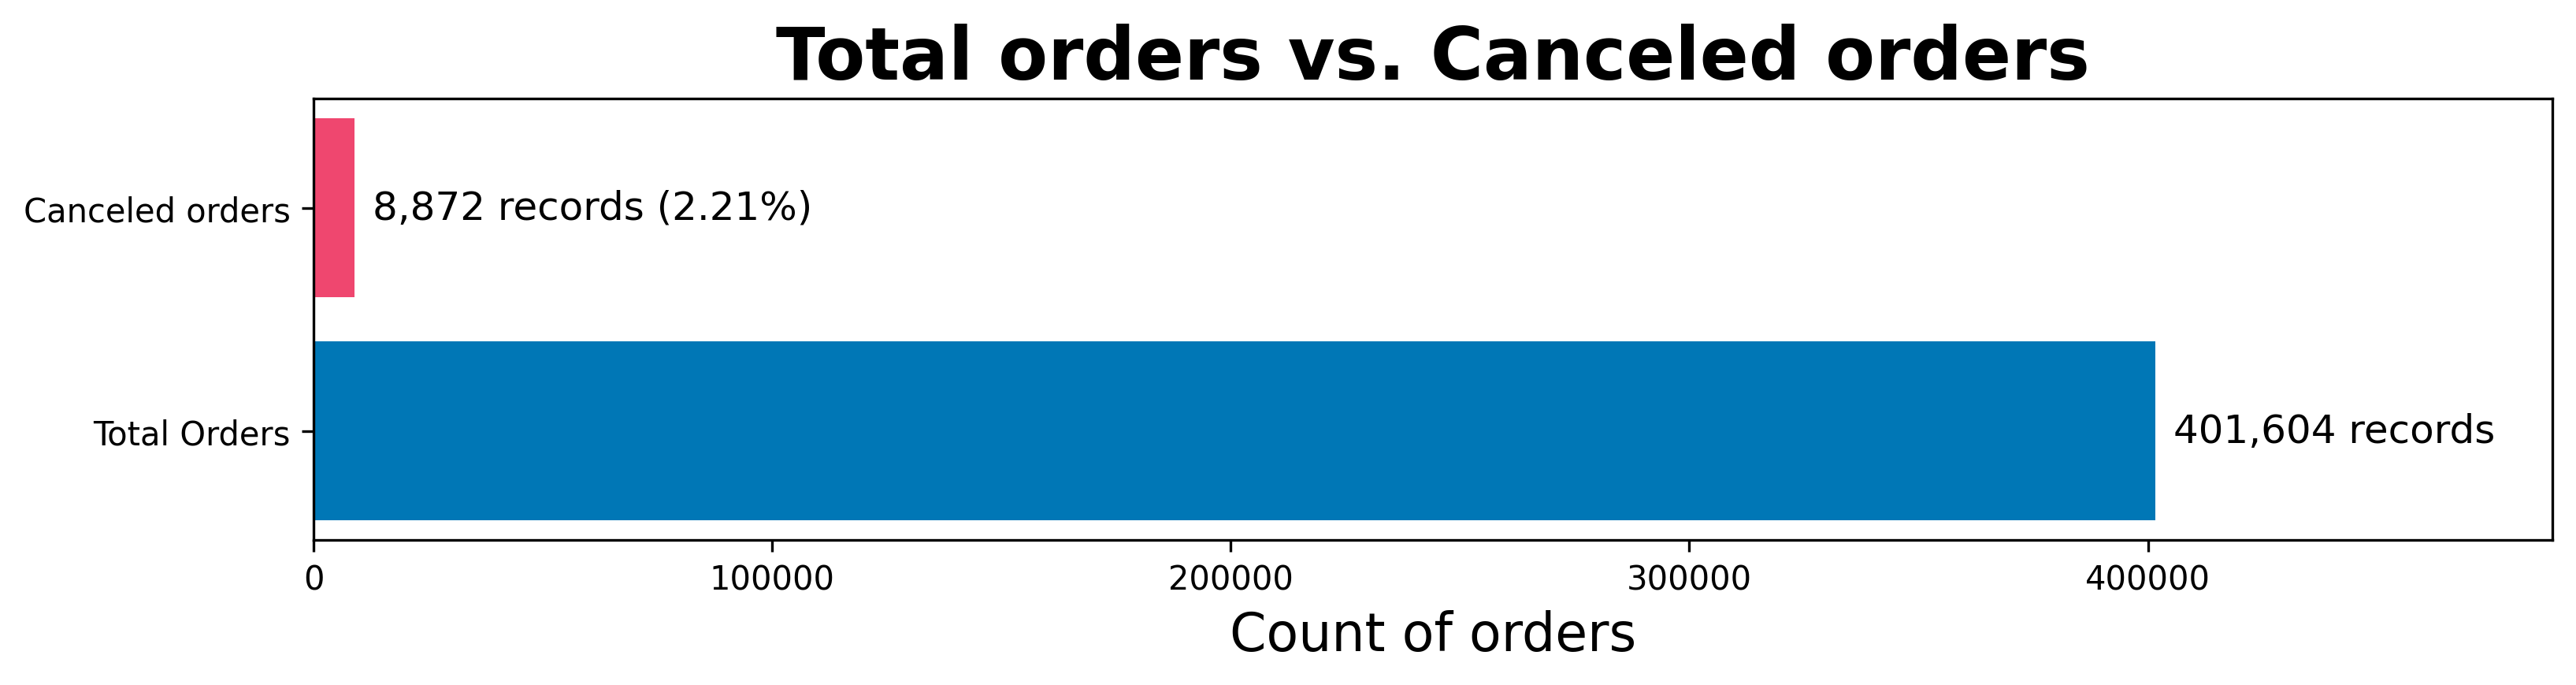

In [65]:
total_orders = df_na_dp_cleaned.shape[0]
tota_canceled_orders = df_canceled.shape[0]
percentage_canceled_orders = float((tota_canceled_orders / total_orders) * 100)

data_labels = ['Total Orders', 'Canceled orders']
data_values = [total_orders, tota_canceled_orders]
colors = ['#0077b6', '#ef476f']
fig, ax = plt.subplots(figsize = (11, 3), dpi = 300)

bars = ax.barh(data_labels, data_values, color = colors)

for i, bar in enumerate(bars):
    value = bar.get_width()
    if i == 0:
        label = f'{value:,} records'
    else:
        label = f'{value:,} records ({percentage_canceled_orders:.2f}%)'
    ax.text(value + 4000, i, label, va = 'center', ha = 'left', fontsize = 12)

ax.set_xlim(0, total_rows * 1.2)
ax.set_title('Total orders vs. Canceled orders', fontweight = 'bold', fontsize = 22)
plt.xlabel('Count of orders', fontsize = 16)
plt.tight_layout()
plt.show()

Next remove the cnceled orders from dataset

In [66]:
df_na_dp_cleaned = df_na_dp_cleaned[~df_na_dp_cleaned['InvoiceNo'].isin(df_canceled['InvoiceNo'])]
df_na_dp_cleaned.head()
df_na_dp_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392732 non-null  object 
 1   StockCode    392732 non-null  object 
 2   Description  392732 non-null  object 
 3   Quantity     392732 non-null  int64  
 4   InvoiceDate  392732 non-null  object 
 5   UnitPrice    392732 non-null  float64
 6   CustomerID   392732 non-null  object 
 7   Country      392732 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 27.0+ MB


#### 2.4.5. Improve datetime data
To allow for better analysis, transform the *InvoiceDate* column to the datetime data format and create two additional columns: *Invoice_date* for storing the date only, and *Invoice_time* for storing the time only.

In [67]:
df_na_dp_cleaned['Invoice_datetime'] = pd.to_datetime(df_na_dp_cleaned['InvoiceDate'], format='%m/%d/%Y %H:%M')
df_na_dp_cleaned = df_na_dp_cleaned.drop(columns = 'InvoiceDate')

In [68]:
df_na_dp_cleaned['Invoice_date'] = df_na_dp_cleaned['Invoice_datetime'].dt.date
df_na_dp_cleaned['Invoice_time'] = df_na_dp_cleaned['Invoice_datetime'].dt.time
df_na_dp_cleaned = df_na_dp_cleaned.loc[:, ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'Invoice_datetime', 'Invoice_date', 'Invoice_time', 'UnitPrice', 'CustomerID', 'Country']]
df_na_dp_cleaned.head()

,InvoiceNo,StockCode,Description,Quantity,Invoice_datetime,Invoice_date,Invoice_time,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2010-12-01,08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,2010-12-01,08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2010-12-01,08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,2010-12-01,08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,2010-12-01,08:26:00,3.39,17850.0,United Kingdom


Save this cleaned dataset to fix the result

For futher steps. Analisys of Quantity column

$$IQR = Q3 - Q1 \rightarrow 10 - 1 = 9$$
$$Upper Fence = Q3 + 1.5 \times IQR \rightarrow 10 + 1.5 \times 9 = 23.5$$
$$Lover Fence = Q1 - 1.5 \times IQR \rightarrow 1 - 1.5 \times 9 = -12,5$$

Add plot in matrix form with set of graphs which shown all columns distribution.

When devided date/time column, answer for:
    - Seasonality: Which months have the highest sales?
    - Weekly Patterns: Do customers shop more on weekends?
    - Daily Cycles: What is the "peak hour" for orders?